In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/titanic_cleaned.csv")
print(df.shape)

(782, 18)


## Question
Does port of embarkation (`embark_town`) affect survival — and if so, is it 
a genuine effect, or does it disappear once we control for passenger class?

In [2]:
by_port = df.groupby("embark_town")["survived"].agg(["mean", "count"])
by_port

,mean,count
embark_town,,
cherbourg,0.580645,155
queenstown,0.338983,59
southampton,0.371479,568


Always showing `count` alongside `mean` here — a port with only a handful of 
passengers would show a noisy, unreliable rate if shown in isolation.

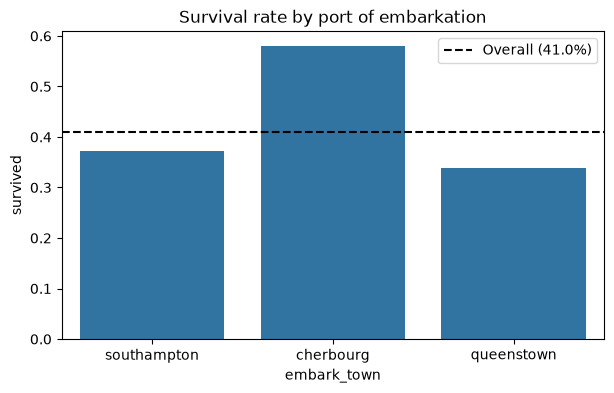

In [3]:
overall_rate = df["survived"].mean()

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="embark_town", y="survived", errorbar=None)
plt.axhline(overall_rate, color="black", linestyle="--", label=f"Overall ({overall_rate:.1%})")
plt.legend()
plt.title("Survival rate by port of embarkation")
plt.show()

In [4]:
by_port_and_class = df.groupby(["embark_town", "pclass"])["survived"].agg(["mean", "count"])
by_port_and_class

mean  count
embark_town pclass                 
cherbourg   1       0.698795     83
            2       0.529412     17
            3       0.418182     55
queenstown  1       0.500000      2
            2       0.666667      3
            3       0.314815     54
southampton 1       0.582677    127
            2       0.503448    145
            3       0.216216    296

In [5]:
# What's the class composition of each port? This is the likely explanation.
class_composition = pd.crosstab(df["embark_town"], df["pclass"], normalize="index")
class_composition

pclass,1,2,3
embark_town,,,
cherbourg,0.535484,0.109677,0.354839
queenstown,0.033898,0.050847,0.915254
southampton,0.223592,0.255282,0.521127


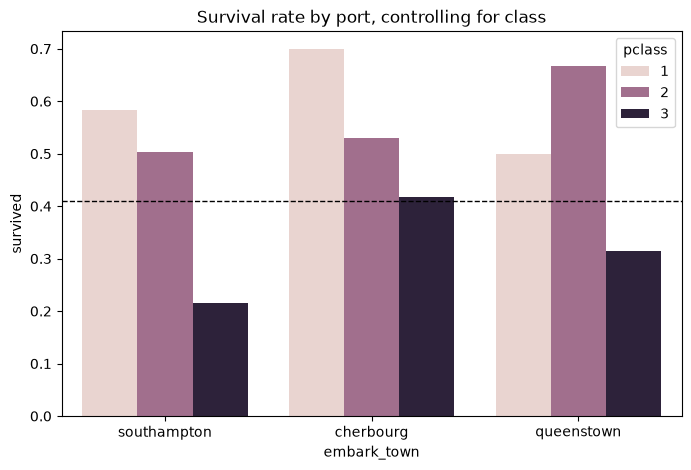

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="embark_town", y="survived", hue="pclass", errorbar=None)
plt.title("Survival rate by port, controlling for class")
plt.axhline(overall_rate, color="black", linestyle="--", linewidth=1)
plt.show()

## Summary — Who's Up, Who's Down, and Why

**Cherbourg passengers survived at 58.1%, well above the 41.0% overall 
average; Southampton (37.1%) and Queenstown (33.9%) sat below it.**

### Checking for Simpson's Paradox
Class composition explains **part** of this gap: Cherbourg carried a much 
higher share of 1st-class passengers (53.5%) than Southampton (22.4%) or 
Queenstown (3.4%, almost entirely 3rd class). 

However, this is **not a full Simpson's Paradox** — the port ranking does not 
reverse once class is controlled for. Cherbourg passengers out-survived 
Southampton passengers within both 1st class (69.9% vs 58.3%) and 3rd class 
(41.8% vs 21.6%). Queenstown's 1st/2nd class figures (n=2 and n=3) are too 
small to draw conclusions from and are excluded from this comparison.

### Conclusion
Port of embarkation has a **genuine effect on survival independent of class**, 
not merely a proxy for it. Cherbourg's advantage is partly explained by 
carrying more 1st-class passengers, but a real port-level effect remains even 
after controlling for class — likely reflecting Cherbourg's position as the 
ship's final major stop, closer to the Atlantic crossing, or other 
port-specific boarding factors not captured in this dataset.